# Cost of Mid-Tier Customer Neglect Using RFM Analysis
## Team 7 - Business Analytics Capstone

This notebook performs:
1. Data Preparation & Cleaning
2. Exploratory Data Analysis (EDA)
3. RFM Feature Engineering
4. Customer Segmentation (Top / Mid / Bottom)

Analysis stops at segmentation as per project methodology.

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt

pd.set_option('display.max_columns', None)

## 1. Data Loading

In [52]:
df = pd.read_csv('Online_Retail.csv', encoding='ISO-8859-1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


## 2. Data Cleaning

In [54]:
# Remove missing CustomerID
df = df.dropna(subset=['CustomerID'])

# Remove negative or zero quantities
df = df[df['Quantity'] > 0]

# Remove negative prices
df = df[df['UnitPrice'] > 0]

# Create TotalPrice column
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom,20.34


## 3. Exploratory Data Analysis (EDA)

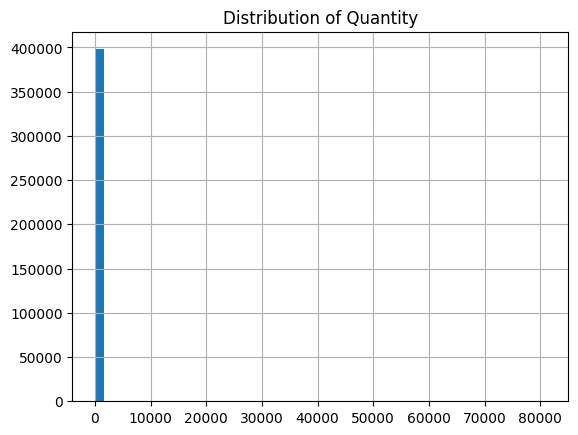

In [55]:
# Distribution of Quantity
plt.figure()
df['Quantity'].hist(bins=50)
plt.title('Distribution of Quantity')
plt.show()

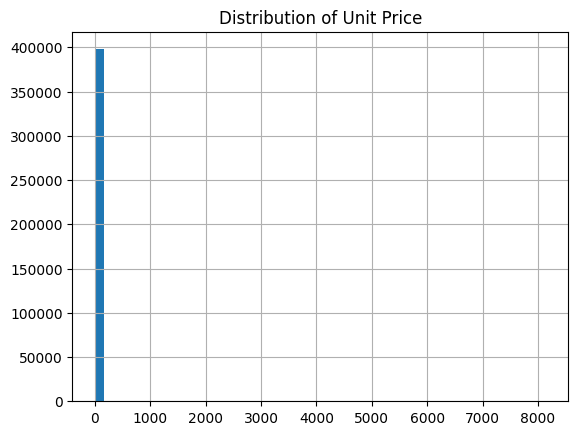

In [56]:
# Distribution of UnitPrice
plt.figure()
df['UnitPrice'].hist(bins=50)
plt.title('Distribution of Unit Price')
plt.show()

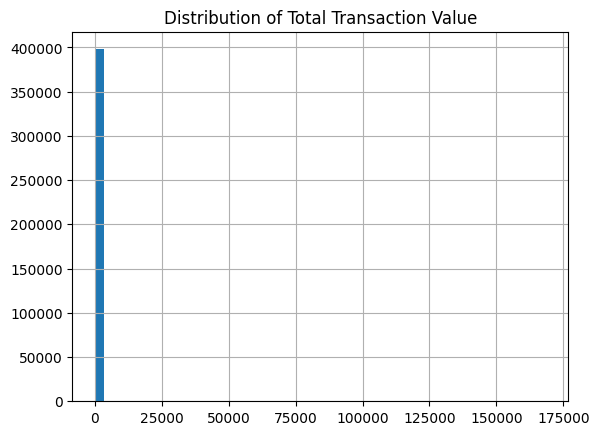

In [57]:
# Distribution of TotalPrice
plt.figure()
df['TotalPrice'].hist(bins=50)
plt.title('Distribution of Total Transaction Value')
plt.show()

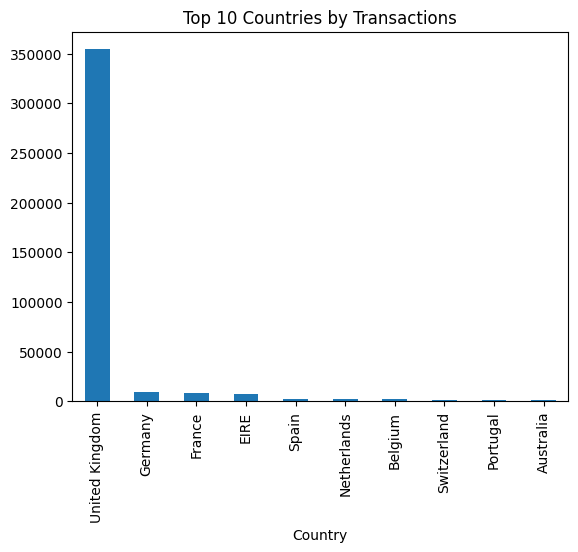

In [58]:
# Transactions per Country
country_counts = df['Country'].value_counts().head(10)
plt.figure()
country_counts.plot(kind='bar')
plt.title('Top 10 Countries by Transactions')
plt.show()

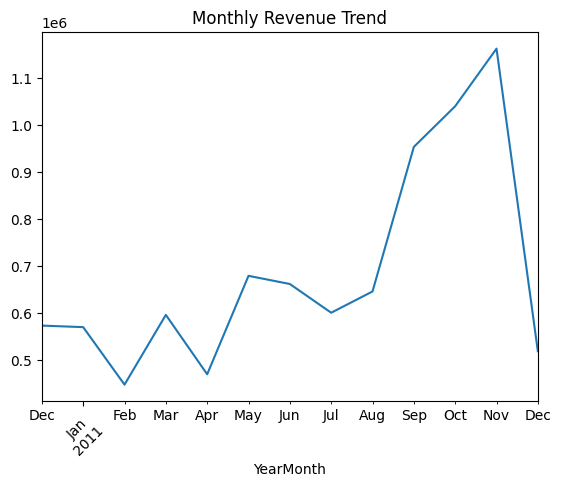

In [ ]:
# Monthly Revenue Trend
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], dayfirst=True)
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

monthly_revenue = df.groupby('YearMonth')['TotalPrice'].sum()

plt.figure()
monthly_revenue.plot()
plt.title('Monthly Revenue Trend')
plt.xticks(rotation=45)
plt.show()

## 4. RFM Feature Engineering

In [60]:
# Snapshot date
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

# Compute RFM metrics
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'count',
    'TotalPrice': 'sum'
})

rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalPrice': 'Monetary'
}, inplace=True)

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,182,4310.00
12348.0,75,31,1797.24
12349.0,19,73,1757.55
12350.0,310,17,334.40


In [61]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,91.720609,2054.266460
std,100.014169,228.785094,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,17.000000,307.415000
50%,51.000000,41.000000,674.485000
75%,142.000000,100.000000,1661.740000
max,374.000000,7847.000000,280206.020000


## 5. RFM Scoring & Customer Segmentation

In [62]:
# Recency: lower is better
rfm['R_score'] = pd.qcut(rfm['Recency'], 3, labels=[3,2,1])

# Frequency: higher is better
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 3, labels=[1,2,3])

# Monetary: higher is better
rfm['M_score'] = pd.qcut(rfm['Monetary'], 3, labels=[1,2,3])

# Combine score
rfm['RFM_Score'] = rfm[['R_score','F_score','M_score']].astype(int).sum(axis=1)

rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,3,5
12347.0,2,182,4310.00,3,3,3,9
12348.0,75,31,1797.24,2,2,3,7
12349.0,19,73,1757.55,3,2,3,8
12350.0,310,17,334.40,1,1,1,3


In [63]:
# Define Tier based on RFM Score
def segment_customer(score):
    if score <= 4:
        return 'Bottom Tier'
    elif score <= 6:
        return 'Mid Tier'
    else:
        return 'Top Tier'

rfm['Customer_Segment'] = rfm['RFM_Score'].apply(segment_customer)

rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Customer_Segment
CustomerID,,,,,,,,
12346.0,326,1,77183.60,1,1,3,5,Mid Tier
12347.0,2,182,4310.00,3,3,3,9,Top Tier
12348.0,75,31,1797.24,2,2,3,7,Top Tier
12349.0,19,73,1757.55,3,2,3,8,Top Tier
12350.0,310,17,334.40,1,1,1,3,Bottom Tier


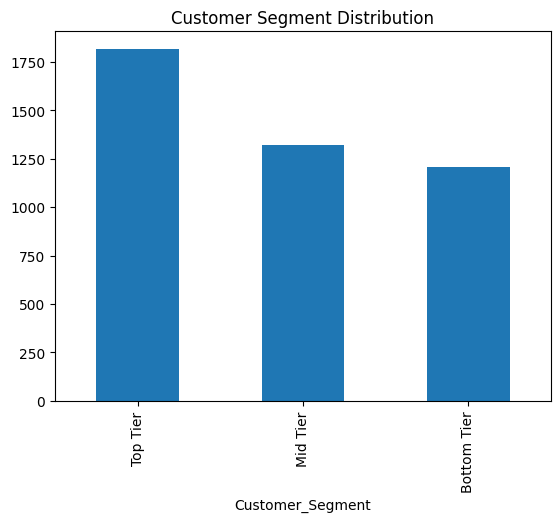

In [64]:
# Segment Distribution
segment_counts = rfm['Customer_Segment'].value_counts()

plt.figure()
segment_counts.plot(kind='bar')
plt.title('Customer Segment Distribution')
plt.show()

In [65]:
# Save segmented dataset
rfm.to_csv('rfm_segmented_output.csv', index=True)

## 6. Extended Segmentation (L, M1, M2, M3, H)

In [66]:
# Create 5-level segmentation using quantiles on RFM Score
rfm['Extended_Segment'] = pd.qcut(rfm['RFM_Score'], 5, labels=['L','M1','M2','M3','H'])

rfm['Extended_Segment'].value_counts()

Extended_Segment
L     1204
M2    1175
M1     697
H      684
M3     578
Name: count, dtype: int64

In [67]:
# Merge segment info back to transaction-level data
df_segmented = df.merge(rfm[['Extended_Segment']], left_on='CustomerID', right_index=True)

df_segmented.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,YearMonth,Extended_Segment
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12,M2
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,M2
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12,M2
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,M2
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12,M2


## 7. Monthly Revenue by Customer Segment (Stacked Bar Chart)

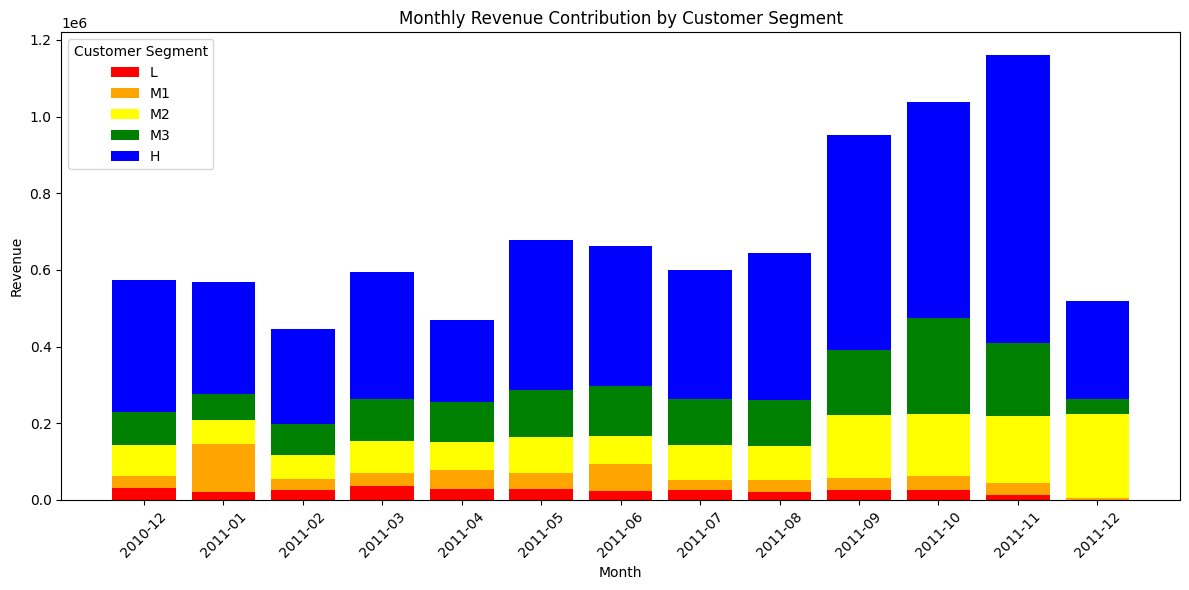

In [68]:
# Monthly revenue by segment
monthly_segment_revenue = (
    df_segmented
    .groupby(['YearMonth', 'Extended_Segment'], observed=False)['TotalPrice']
    .sum()
    .unstack()
)

# Convert Period to string for plotting
monthly_segment_revenue.index = monthly_segment_revenue.index.astype(str)

# Plot stacked bar chart
plt.figure(figsize=(12,6))

bottom = np.zeros(len(monthly_segment_revenue))
colors = ['red','orange','yellow','green','blue']

for i, segment in enumerate(monthly_segment_revenue.columns):
    plt.bar(monthly_segment_revenue.index,
            monthly_segment_revenue[segment],
            bottom=bottom,
            label=segment,
            color=colors[i])
    bottom += monthly_segment_revenue[segment].values

plt.xticks(rotation=45)
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.title('Monthly Revenue Contribution by Customer Segment')
plt.legend(title='Customer Segment')
plt.tight_layout()
plt.show()